# Multiple Linked Views with Matplotlib
This notebook demonstrates a robust linked-view example for VS Code notebooks using only Matplotlib and `ipympl`.

> Interaction
- Drag a rectangle in the scatter plot to select cars.
- The bar chart updates to show the distribution of selected car body styles.
- Press `c` while the figure is focused to clear the current selection.

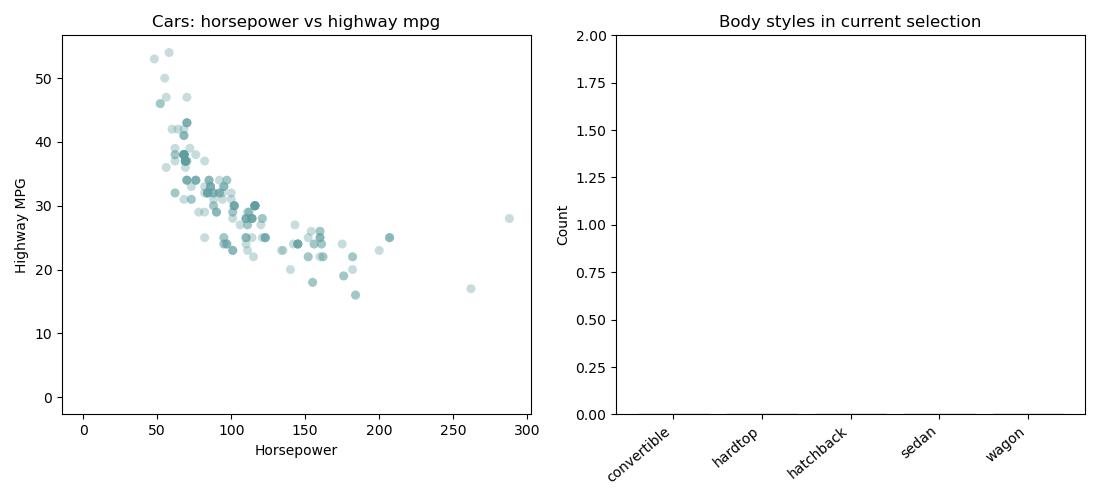

In [1]:
%matplotlib ipympl

import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

# resolve the data file from common VS Code notebook working directories
candidate_paths = [
    pathlib.Path('../../data/imports-85.csv'),
    pathlib.Path('../data/imports-85.csv'),
    pathlib.Path('data/imports-85.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find data/imports-85.csv from the current notebook working directory.')

cars_df = pd.read_csv(data_path)

# keep only rows that are usable for this small interactive example
plot_df = cars_df[['horsepower', 'highway-mpg', 'body-style']].copy()
plot_df['horsepower'] = pd.to_numeric(plot_df['horsepower'], errors='coerce')
plot_df['highway-mpg'] = pd.to_numeric(plot_df['highway-mpg'], errors='coerce')
plot_df = plot_df.dropna().reset_index(drop=True)

body_styles = sorted(plot_df['body-style'].unique())
style_to_index = {style: index for index, style in enumerate(body_styles)}
base_color = np.array([95 / 255, 158 / 255, 160 / 255, 0.35])
highlight_color = np.array([178 / 255, 34 / 255, 34 / 255, 0.9])
facecolors = np.tile(base_color, (len(plot_df), 1))

fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(11, 5))
fig.canvas.header_visible = False

scatter = ax_scatter.scatter(
    plot_df['horsepower'],
    plot_df['highway-mpg'],
    s=42,
    facecolors=facecolors,
    edgecolors='none',
)
ax_scatter.set_title('Cars: horsepower vs highway mpg')
ax_scatter.set_xlabel('Horsepower')
ax_scatter.set_ylabel('Highway MPG')

bar_positions = np.arange(len(body_styles))
bar_container = ax_bar.bar(
    bar_positions,
    np.zeros(len(body_styles), dtype=int),
    color='lightsteelblue',
    edgecolor='slategray',
)
ax_bar.set_xticks(bar_positions)
ax_bar.set_xticklabels(body_styles, rotation=40, ha='right')
ax_bar.set_title('Body styles in current selection')
ax_bar.set_ylabel('Count')
ax_bar.set_ylim(0, max(1, plot_df['body-style'].value_counts().max()))

selection_mask = np.zeros(len(plot_df), dtype=bool)

def redraw_views():
    updated_colors = np.tile(base_color, (len(plot_df), 1))
    if selection_mask.any():
        updated_colors[selection_mask] = highlight_color
    scatter.set_facecolors(updated_colors)

    counts = plot_df.loc[selection_mask, 'body-style'].value_counts()
    max_count = 1
    for bar, style in zip(bar_container, body_styles):
        count = int(counts.get(style, 0))
        bar.set_height(count)
        max_count = max(max_count, count)

    ax_bar.set_ylim(0, max_count + 1)
    fig.canvas.draw_idle()

def clear_selection(event=None):
    selection_mask[:] = False
    redraw_views()

def update_selection(eclick, erelease):
    if eclick.xdata is None or erelease.xdata is None:
        return
    if eclick.ydata is None or erelease.ydata is None:
        return

    x_min, x_max = sorted([eclick.xdata, erelease.xdata])
    y_min, y_max = sorted([eclick.ydata, erelease.ydata])

    x = plot_df['horsepower'].to_numpy()
    y = plot_df['highway-mpg'].to_numpy()
    selection_mask[:] = (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    redraw_views()

def handle_key(event):
    if event.key == 'c':
        clear_selection()

selector = RectangleSelector(
    ax_scatter,
    update_selection,
    useblit=False,
    button=[1],
    minspanx=5,
    minspany=5,
    spancoords='pixels',
    interactive=True,
    drag_from_anywhere=True,
    props={'facecolor': 'firebrick', 'alpha': 0.12, 'edgecolor': 'firebrick'},
)

fig.canvas.mpl_connect('key_press_event', handle_key)
redraw_views()
plt.tight_layout()
plt.show()